<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C6_Clustering_(Libro).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase N° 6: Clustering en Minería de Datos**

El clustering es una de las técnicas más utilizadas en minería de datos para descubrir patrones ocultos en grandes volúmenes de información. A diferencia del aprendizaje supervisado, el clustering es una técnica de aprendizaje no supervisado, lo que significa que no se cuenta con etiquetas previas para los datos.

**Importancia del Clustering en Minería de Datos**

    * Segmentación de clientes en marketing para mejorar estrategias de ventas.
    * Agrupación de documentos y textos en sistemas de recomendación.
    * Detección de anomalías en transacciones bancarias o ciberseguridad.
    * Clasificación automática de imágenes y datos biomédicos.

## 1.1. Características del Clustering

    * No supervisado: No requiere etiquetas previas en los datos.
    * Identifica patrones ocultos en los datos sin intervención humana.
    * Los resultados dependen del algoritmo elegido y de los parámetros utilizados.

## 1.2. Tipos de Clustering

| Tipo de Clustering       | Descripción                                   | Ejemplo de Uso                 |
|:-------------------------|:----------------------------------------------|:-------------------------------|
| Particional              | Divide los datos en un número fijo de grupos. | K-Means, K-Medoids             |
| Jerárquico               | Crea una estructura de árbol para los clusters. | Dendrogramas en biología       |
| Basado en densidad       | Agrupa datos en regiones de alta densidad.    | DBScan para detección de anomalías |
| Basado en redes neuronales | Utiliza modelos autoorganizados.              | SOM en análisis de imágenes    |

**¿Cómo elegir un tipo de clustering?**

    * Si se conoce el número de grupos → K-Means o K-Medoids.
    * Si hay ruido o valores atípicos en los datos → DBScan.
    * Si se quiere entender jerarquías en los datos → Clustering jerárquico.
    * Si se necesita aprender representaciones complejas → SOM (Self-Organizing Maps).

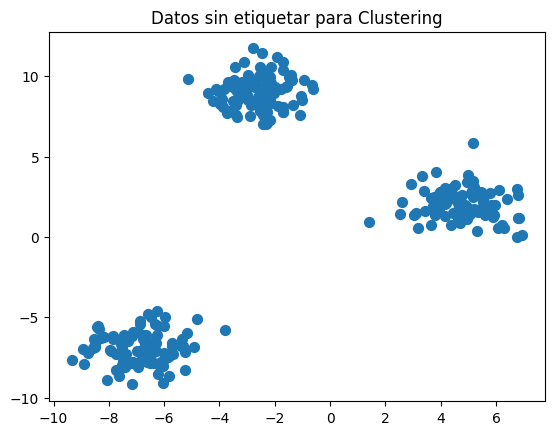

Conclusión:

   Se observa que los datos tienen patrones naturales que pueden ser agrupados mediante clustering.


In [ ]:
#1.3. Ejemplo en Python – Creación de un Conjunto de Datos Sintético
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar dataset sintético con 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Graficar los datos sin etiquetas
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Datos sin etiquetar para Clustering")
plt.show()

print('Conclusión:\n')
print('   Se observa que los datos tienen patrones naturales que pueden ser agrupados mediante clustering.')

# **Sección 2: Algoritmo K-Means**

Objetivo: Comprender el funcionamiento del algoritmo K-Means, su proceso iterativo y cómo aplicarlo en un conjunto de datos.
2.1. ¿Qué es K-Means?

    K-Means es un algoritmo de clustering particional que divide los datos en K grupos basados en la minimización de la variación dentro de cada cluster.
    Se basa en la distancia euclidiana para asignar puntos a los clusters más cercanos.
    Es uno de los métodos más utilizados debido a su simplicidad y eficiencia computacional.


2.2. Funcionamiento del Algoritmo

El proceso de K-Means sigue estos pasos:

1. Seleccionar el número de clusters K.
2. Inicializar los centroides de forma aleatoria.
3. Asignar cada punto al centroide más cercano.
4. Actualizar los centroides recalculando la media de cada cluster.
5. Repetir los pasos 3 y 4 hasta que los centroides no cambien significativamente.


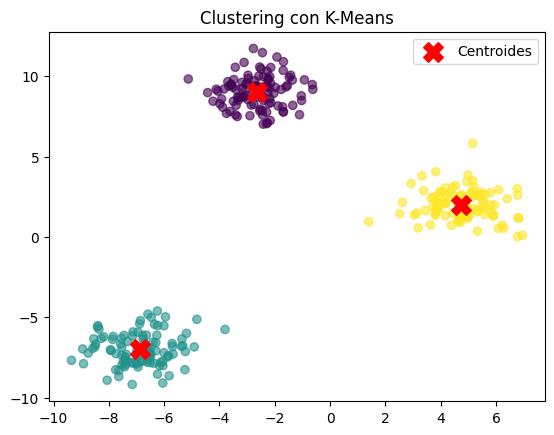

Conclusión:

    Cada color representa un cluster asignado por K-Means.
    Los centroides en rojo indican los centros de cada grupo.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generar datos sintéticos con 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Graficar clusters y centroides
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")
plt.title("Clustering con K-Means")
plt.legend()
plt.show()

print('Conclusión:\n')
print('    Cada color representa un cluster asignado por K-Means.')
print('    Los centroides en rojo indican los centros de cada grupo.')


# 2.3. Elección del Número de Clusters K

Uno de los desafíos de K-Means es elegir el número óptimo de clusters. Los principales métodos son:

1. Método del Codo (Elbow Method): Calcula la suma de errores cuadrados para diferentes valores de K.
2. Índice de Silhouette: Mide la cohesión y separación de los clusters.


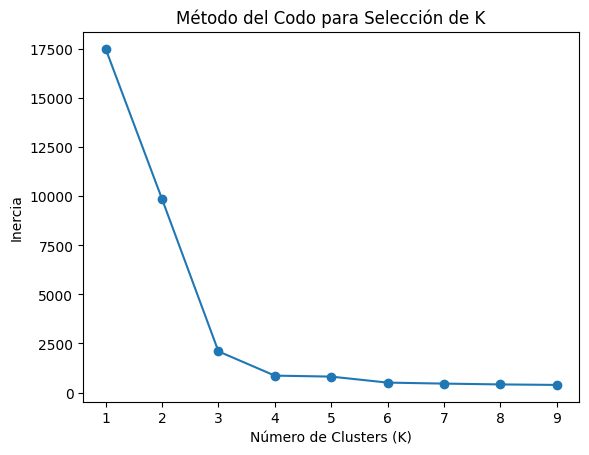

Conclusión:

   Se elige el punto donde la inercia deja de disminuir abruptamente, es decir, el "codo" de la curva.


In [ ]:
# Ejemplo en Python – Método del Codo

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generar datos
X, y = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)

# Calcular la inercia para diferentes valores de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Selección de K")
plt.show()

print('Conclusión:\n')
print('   Se elige el punto donde la inercia deja de disminuir abruptamente, es decir, el "codo" de la curva.')

# Sección 3: DBScan y Clustering Basado en Densidad

**Objetivo**: Comprender el funcionamiento del algoritmo DBScan, sus ventajas sobre K-Means y cómo aplicarlo en Python.

**3.1. ¿Qué es DBScan?**

DBScan (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de clustering basado en densidad que no requiere especificar el número de clusters. Identifica áreas de alta densidad separadas por regiones de baja densidad, lo que permite detectar clusters de formas arbitrarias y manejar outliers de manera más efectiva que K-Means.

Ventajas de DBScan

    No requiere definir K de antemano.
    Puede detectar clusters con formas irregulares.
    Maneja bien el ruido y outliers en los datos.

Desventajas de DBScan

    No funciona bien si las densidades de los clusters son muy diferentes.
    Puede ser lento en datasets grandes.


**3.2. Funcionamiento del Algoritmo**

El algoritmo DBScan se basa en dos parámetros clave:

* ε (Epsilon): Determina la distancia máxima entre puntos vecinos.
* minPts (Mínimo de puntos por cluster): Define cuántos puntos se requieren para formar un grupo denso.

Cómo funciona:

    1. Se selecciona un punto y se busca cuántos vecinos tiene en un radio ε.
    2. Si hay al menos minPts vecinos, el punto se convierte en "punto núcleo" y se expande el cluster.
    3. Si el punto tiene menos vecinos, se marca como "punto de ruido" (outlier).
    4. Se repite hasta que todos los puntos han sido visitados.


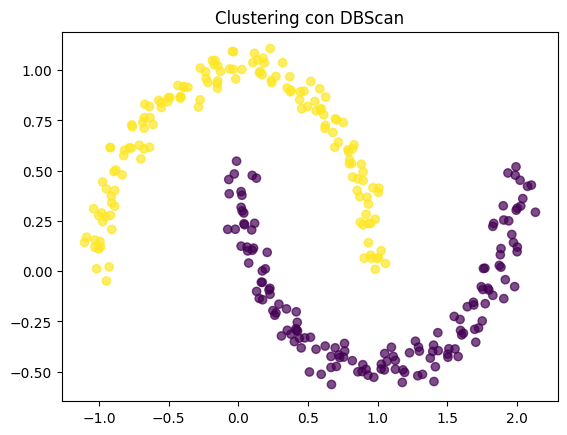

Conclusión:

    DBScan detecta formas de clusters más complejas que K-Means.
    Los puntos marcados como -1 son outliers que no pertenecen a ningún cluster.


In [ ]:
# 3.3. Ejemplo en Python – Aplicando DBScan

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generar datos con forma de media luna (difícil para K-Means)
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X)

# Visualizar resultados
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.title("Clustering con DBScan")
plt.show()

print('Conclusión:\n')
print('    DBScan detecta formas de clusters más complejas que K-Means.')
print('    Los puntos marcados como -1 son outliers que no pertenecen a ningún cluster.')


# 3.4. Comparación entre K-Means y DBScan

| Característica        | K-Means                 | DBScan                     |
|:----------------------|:------------------------|:---------------------------|
| Tipo de Clustering    | Basado en particiones   | Basado en densidad         |
| Forma de los Clusters | Esféricos               | Arbitrarias                |
| Sensibilidad a Outliers | Alta                    | Baja                       |
| Número de Clusters    | Debe definirse antes (K)| Se detecta automáticamente |
| Uso Recomendado       | Cuando los clusters son bien definidos | Cuando hay formas complejas y ruido |

¿Cuándo usar DBScan?

    * Si los clusters tienen formas no esféricas.
    * Si hay valores atípicos en los datos.
    * Si no sabemos de antemano el número de clusters.

# Sección 4: Evaluación de la Calidad del Clustering

**Objetivo**: Aprender a medir la calidad de los clusters generados con diferentes algoritmos mediante métricas de evaluación.

**4.1. ¿Por qué evaluar un Clustering?**

A diferencia del aprendizaje supervisado, en clustering no tenemos etiquetas verdaderas, lo que hace difícil evaluar si los clusters son correctos. Existen métricas que miden la cohesión interna y la separación entre clusters.

**Métricas más utilizadas en clustering**

| Métrica                     | Descripción                                                                 | Cuándo Usarla                               |
|:----------------------------|:----------------------------------------------------------------------------|:--------------------------------------------|
| Inercia (SSE)               | Mide la suma de distancias de cada punto a su centroide (menor es mejor).   | Evaluar K-Means.                            |
| Coeficiente de Silhouette   | Mide cuán similares son los puntos dentro de un cluster frente a otros (rango -1 a 1, mayor es mejor). | Comparar diferentes algoritmos de clustering. |
| Índice de Davies-Bouldin (DBI) | Evalúa la compactación de los clusters y la distancia entre ellos (menor es mejor). | Comparar calidad general del clustering.    |

# **4.2. Aplicando Métricas de Evaluación en Python**

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Cargar dataset de iris
df = sns.load_dataset("iris")
X = df[["sepal_length", "sepal_width"]].values

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df["Cluster_KMeans"] = kmeans.fit_predict(X)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.7, min_samples=5)
df["Cluster_DBScan"] = dbscan.fit_predict(X)

# Evaluar con Silhouette Score
silhouette_kmeans = silhouette_score(X, df["Cluster_KMeans"])
mask = df["Cluster_DBScan"] != -1
dbscan_labels_filtered = df["Cluster_DBScan"][mask]

# Check if there are enough clusters for DBSCAN to calculate silhouette score
if len(np.unique(dbscan_labels_filtered)) > 1:
    silhouette_dbscan = silhouette_score(X[mask], dbscan_labels_filtered)
    dbi_dbscan = davies_bouldin_score(X[mask], dbscan_labels_filtered)
else:
    silhouette_dbscan = np.nan # Or choose a suitable value/message
    dbi_dbscan = np.nan # Or choose a suitable value/message
    print('Advertencia: DBSCAN no formó al menos 2 clústeres (excluyendo el ruido) para la evaluación. No se pueden calcular las puntuaciones Silhouette y Davies-Bouldin para DBSCAN.')


# Evaluar con Davies-Bouldin Index
dbi_kmeans = davies_bouldin_score(X, df["Cluster_KMeans"])

print(f"Silhouette - K-Means: {silhouette_kmeans:.2f}")
print(f"Silhouette - DBScan:  {silhouette_dbscan:.2f}")
print(f"Davies-Bouldin - K-Means: {dbi_kmeans:.2f}")
print(f"Davies-Bouldin - DBScan:  {dbi_dbscan:.2f}")

print('\nConclusión:\n')
print('    Un mayor coeficiente de Silhouette indica clusters bien formados.')
print('    Un menor Davies-Bouldin Index significa clusters más compactos y separados.')


Advertencia: DBSCAN no formó al menos 2 clústeres (excluyendo el ruido) para la evaluación. No se pueden calcular las puntuaciones Silhouette y Davies-Bouldin para DBSCAN.
Silhouette - K-Means: 0.45
Silhouette - DBScan:  nan
Davies-Bouldin - K-Means: 0.77
Davies-Bouldin - DBScan:  nan

Conclusión:

    Un mayor coeficiente de Silhouette indica clusters bien formados.
    Un menor Davies-Bouldin Index significa clusters más compactos y separados.


# **4.3. Interpretación de Resultados**

¿Qué hacer si la métrica indica un clustering deficiente?

* Probar otro algoritmo de clustering (si K-Means falla, intentar DBScan).
* Ajustar hiperparámetros (K en K-Means o ε en DBScan).
* Aplicar reducción de dimensionalidad (PCA) para mejorar la separación de clusters.


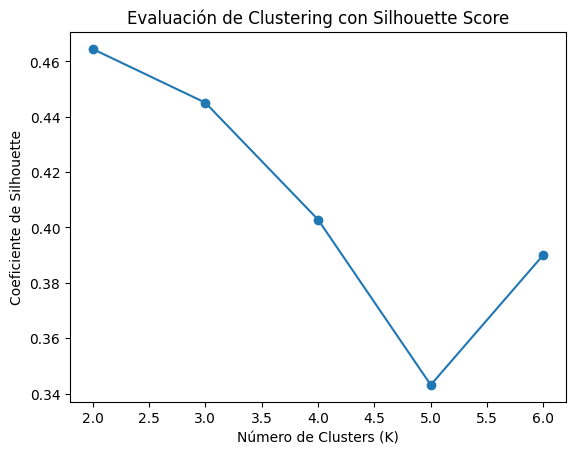

Conclusión:

    Un pico en la curva indica el número óptimo de clusters.
    Si no hay un claro máximo, puede ser útil probar otros algoritmos.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Probar K-Means con diferentes valores de K
valores_k = range(2, 7)
silhouette_scores = []
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, clusters))

# Graficar Silhouette Score vs. K
plt.plot(valores_k, silhouette_scores, marker="o")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Evaluación de Clustering con Silhouette Score")
plt.show()

print('Conclusión:\n')
print('    Un pico en la curva indica el número óptimo de clusters.')
print('    Si no hay un claro máximo, puede ser útil probar otros algoritmos.')


# **Sección 5: Ejercicio Integrador Obligatorio**
Desarrollado en archivo separado.